---
# Metody liniowe
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from ucimlrepo import fetch_ucirepo 
from feature_engine.encoding import RareLabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr

In [2]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

'1.7.1'

# Przykład - [Computer Hardware](https://archive.ics.uci.edu/dataset/29/computer+hardware)

Zajmiemy się problemem regresji liniowej na przykładzie przewidywania względnej wydajności CPU

## Załadowanie danych

In [3]:
computer_hardware = fetch_ucirepo(id=29) 
X = computer_hardware.data.features 
y = computer_hardware.data.targets 

In [4]:
X.shape, len(y)

TypeError: object of type 'NoneType' has no len()

Coś jest nie tak...

Wybieramy poprawną kolumnę dla `y` zgodnie z dokumentacją

In [5]:
y = X.pop('PRP')

Usuwamy też następujące kolumny ze zbioru `X`:
- `ERP` wartości uzyskane z modelu liniowego przez autorów (patrz dokumentacja)
- `ModelName` jedna z kolumn identyfikującej rekordy

In [6]:
X = X.drop(columns=['ERP', 'ModelName'])

In [7]:
X.shape, len(y)

((209, 7), 209)

## Wstępne przetwarzanie danych

### Brakujące dane

In [8]:
X[pd.isna(X).any(axis=1)]

,VendorName,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX


Nie ma brakujących danych. W takim razie dokonujemy "zepsucia" danych, a następnie używamy [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)

In [9]:
X.loc[204, 'VendorName'] = np.nan

In [10]:
# podmieniamy dane za pomocą dominanty
# (w zasadzie najpopularniejsza metoda dla danych tekstowych)
simp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
X = simp.fit_transform(X)

In [11]:
# Czy podmiana zaszła zgodnie z oczekiwaniami?
assert X.loc[204, 'VendorName'] == X.VendorName.value_counts().index[0]

- Taką samą funkcjonalność możemy uzyskać za pomocą [pandas.DataFrame.fillna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Zaletą `SimpleImputer` jest to, że możemy go włączyć w piepline zob. [Imputing missing values before building an estimator](https://scikit-learn.org/stable/auto_examples/impute/plot_missing_values.html) i połączyć np. z metodą do skalowania / normalizacji
- Zobacz również API do [IterativeImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html)

### Zmienne kategoryczne

#### Usuwanie rzadkich kategorii
- Zauważmy, że `VendorName` posiada sporo kategorii, spośród których wiele jest rzadkich. Najlepiej połączyć je w jedną kategorię
- W tym celu użyjemy [RareLabelEncoder](https://feature-engine.trainindata.com/en/1.8.x/api_doc/encoding/RareLabelEncoder.html)
- **Uwaga:** jeśli mamy kilka większych grup, od których silnie zależy zmienna zależna, warto rozważyć [liniowy model efektów mieszanych](https://en.wikipedia.org/wiki/Mixed_model) - może się np. zdażyć, że zależność dla jednej grupy będzie dodatnia, a dla innej - ujemna. Wówczas zwykły model liniowy nie będzie w stanie uchwycić tego efektu

In [12]:
X.VendorName.nunique()

30

In [13]:
rare_label_encoder = RareLabelEncoder(n_categories=10, tol=0.05)

In [14]:
X['VendorName'] = rare_label_encoder.fit_transform(X[['VendorName']])

/Users/pawel/miniconda3/envs/pum2/lib/python3.13/site-packages/feature_engine/variable_handling/_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)


In [15]:
X.VendorName.value_counts()

VendorName
Rare         107
ibm           33
nas           19
honeywell     13
ncr           13
siemens       12
sperry        12
Name: count, dtype: int64

Teraz możemy przejść do transformacji za pomocą one-hot encoding ([OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html))

#### One-hot encoding - przykład

Zacznijmy od prostego przykładu, żeby zrozumieć, jak działa *one-hot encoding*

In [16]:
enc = OneHotEncoder(drop='first', sparse_output=False)
XX = pd.DataFrame([['Cat', 1], ['Dog', 3], ['Cat', 2], ['Unknown', 4]])

In [17]:
XX

,0,1
0,Cat,1
1,Dog,3
2,Cat,2
3,Unknown,4


In [18]:
enc.fit_transform(XX[[0]])

,x0_Dog,x0_Unknown
0,0.0,0.0
1,1.0,0.0
2,0.0,0.0
3,0.0,1.0


#### One-hot encoding - nasze dane

A teraz wróćmy do naszego problemu

In [19]:
vendor_features = enc.fit_transform(X[['VendorName']])

In [20]:
X_enc = X.drop(columns='VendorName').join(vendor_features)

Podobną funkcjonalność ma [pandas.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) z argumentem `drop_first=True`)

### Zmienne skorelowane

Rzućmy okiem na korelację dwóch grup cech:

In [21]:
# (Nowe) zmienne tekstowe
corrs_txt = vendor_features.corr()
# Zmienne numeryczne
corrs_num = X_enc.drop(columns=vendor_features.columns).corr()

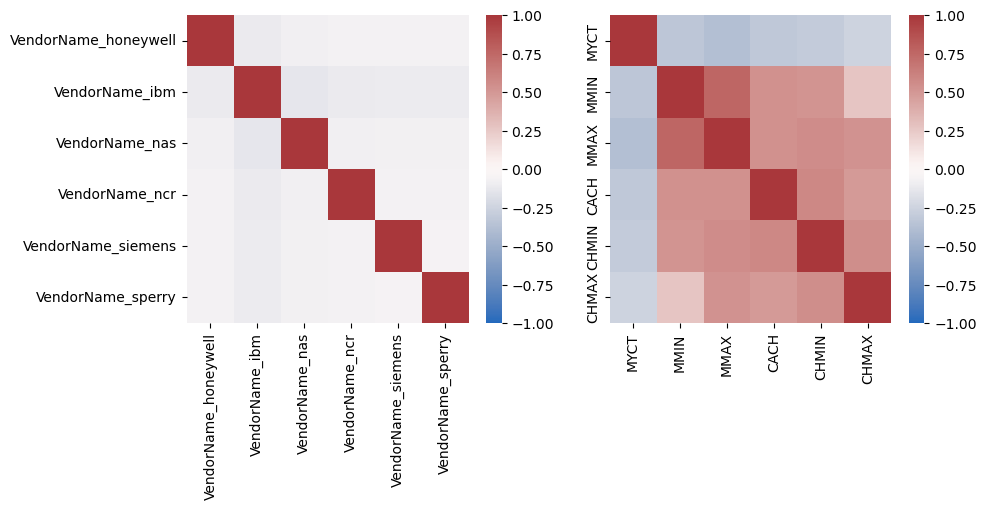

In [22]:
kwargs = {'cmap': 'vlag', 'vmin': -1, 'vmax': 1}
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(corrs_txt, ax=ax[0], **kwargs)
sns.heatmap(corrs_num, ax=ax[1], **kwargs)
plt.show()

- Jedynie jedna para ma całkiem wysoką korelację
- Usuńmy jedną zmienną z tej pary
- **Uwaga 1:** w rzeczywistych zastosowaniach lepiej wybrać wyższy próg np. 0.8-0.9 albo użyć regularyzacji
- **Uwaga 2:** nie musimy pisać własnej funkcji - możemy też użyć [SmartCorrelatedSelection](https://feature-engine.trainindata.com/en/1.8.x/user_guide/selection/SmartCorrelatedSelection.html), co jest zalecane

In [23]:
corrs_num.loc['MMIN', 'MMAX']

np.float64(0.758157347803723)

In [24]:
def remove_highly_correlated_features(df, threshold=0.8):
    """
    Usuwa cechy o korelacji >= threshold, zachowując tę o wyższej wariancji

    Parametry:
        df (pd.DataFrame): dane wejściowe
        threshold (float): próg korelacji do usunięcia

    Zwraca:
        pd.DataFrame: dane ze zredukowanymi cechami
    """
    # Oblicz macierz korelacji i jej górny trójkąt
    corr_matrix = df.corr()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    # Identyfikacja cech do usunięcia
    to_drop = {
        column if df[column].var() < df[feature].var() else feature
        for column in upper_tri.columns
        for feature in upper_tri.index[upper_tri[column] >= threshold]
    }
    return df.drop(columns=to_drop)

In [25]:
X_enc_uncorr = remove_highly_correlated_features(X_enc, 0.7)

### Standardyzacja / normalizacja

- Generalnie, zawsze warto wypróbować zarówno standardyzację jak i normalizację (ale np. dla danych kompozycyjnych tj. proporcji to nie zadziała - wtedy trzeba użyć transformacji logatytmycznych typu *centered log-ratio*)
- Skalowaniu powinny podlegać przede wszystkim zmienne ciągłe
- Zmienne kategoryczne po tranformacji one-hot można, ale nie trzeba skalować (chyba że chcemy mieć bardziej klarowną interpretację wyrazu wolnego regresji)

In [26]:
scaler = StandardScaler()
X_enc_uncorr_scaled = scaler.fit_transform(X_enc_uncorr)

## Model liniowy

### Podział danych na zbiór treningowy i testowy

**Uwaga:** w rzeczywistości nasz zbiór testowy to zbiór walidacyjny tzn. zbiór wykorzystywany bezpośrednio do dostrajania hiperparametrów

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_enc_uncorr_scaled,
                                                    y, test_size=0.2, random_state=0)

### Tranujemy model

Zaczynamy od domyślnych hiperparametrów

In [28]:
reg_linear = LinearRegression()
reg_linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Sprawdzamy wyniki
- Generalnie, im więcej sposobów pomiaru wydajności modelu, tym lepiej, ale trzeba każdy z nich umieć zinterpretować!
- Poniżej stosujemy RMSE oraz MAE - pierwszy uwypukla błąd daleko od mediany, drugi - blisko mediany
- Podobnie, sprawdzamy współczynniki korelacji Pearsona i Spermana dla wartości przewidzianych i oczekiwanych, żeby zobaczyć, czy trend dla obu jest podobny
- Wykres `y` przeciw `y_pred` może być również pomocny m.in. w zdiagnozowaniu obszaru (obszarów), gdzie model radzi sobie gorzej

#### Przewidywania modelu

In [29]:
y_pred_train = reg_linear.predict(X_train)
y_pred_test  = reg_linear.predict(X_test)

#### RMSE, MAE

In [30]:
root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_test, y_pred_test)

(68.952895638737, 61.236155731732)

In [31]:
mean_absolute_error(y_train, y_pred_train), mean_absolute_error(y_test, y_pred_test)

(44.17005855291142, 47.34500454986595)

#### Współczynniki korelacji

In [32]:
pearsonr(y_train, y_pred_train)[0], pearsonr(y_test, y_pred_test)[0]

(np.float64(0.9122083180373266), np.float64(0.8823822587966444))

In [33]:
spearmanr(y_train, y_pred_train)[0], spearmanr(y_test, y_pred_test)[0]

(np.float64(0.8451987552961482), np.float64(0.8714291567282909))

Na pierwszy rzut oka, wyniki są całkiej niezłe, ale bardzo rzadko domyślne hiperparametry są tymi optymalnymi